Trajectory plot saved to /home/users/xzh/trajectory-prediction/trajectory_plot.png


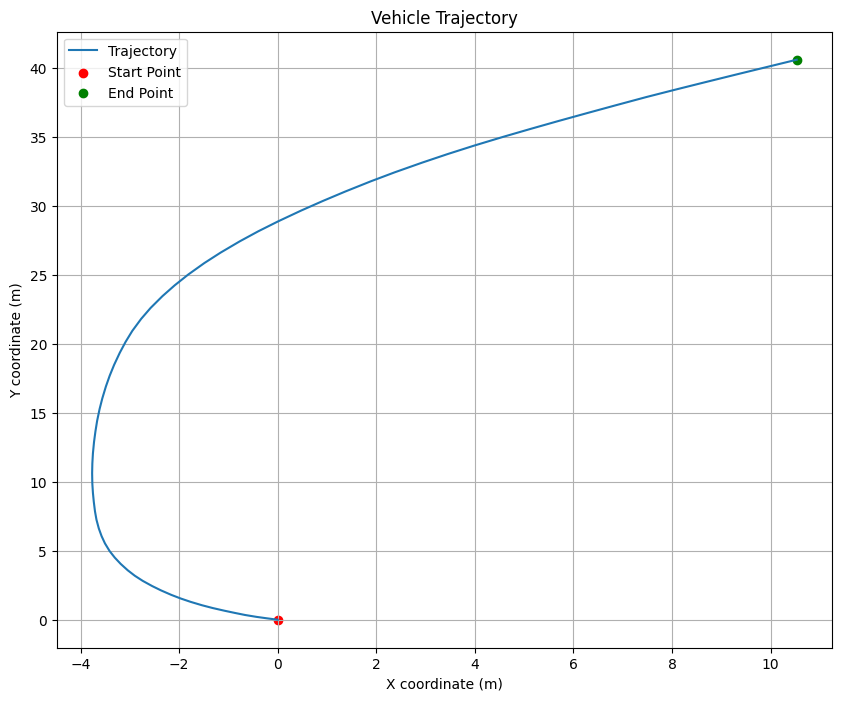

In [ ]:
import os
import numpy as np
import utm
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt

class OxtData:
    def __init__(self, lat, lon, alt, roll, pitch, yaw, pos_accuracy):
        self.lat = lat
        self.lon = lon
        self.alt = alt
        self.roll = roll
        self.pitch = pitch
        self.yaw = yaw
        self.pos_accuracy = pos_accuracy

class EgoPose:
    def __init__(self, translation, rotation, position_variance):
        self.translation = translation
        self.rotation = rotation
        self.position_variance = position_variance

def parse_pose_from_oxt(oxt: OxtData) -> EgoPose:
    # Convert latitude and longitude to UTM coordinates
    x, y, _, _ = utm.from_latlon(oxt.lat, oxt.lon)
    t = [x, y, oxt.alt]

    # Create a rotation object from Euler angles (roll, pitch, yaw)
    r = R.from_euler('xyz', [oxt.roll, oxt.pitch, oxt.yaw], degrees=True)

    # Initialize the EgoPose with the translation, rotation, and position variance
    return EgoPose(t, r.as_matrix(), np.eye(3) * oxt.pos_accuracy)

def read_oxt_file(file_path):
    with open(file_path, 'r') as file:
        line = file.readline()
        data = list(map(float, line.split()))
        # Assuming the order of data is: lat, lon, alt, roll, pitch, yaw, pos_accuracy
        oxt_data = OxtData(*data[:7])
    return oxt_data


def plot_trajectory(file_paths, output_path):
    # List to store translations
    translations = []

    for file_path in file_paths:
        # Read the OXTS data from the file
        oxt_data = read_oxt_file(file_path)

        # Parse the pose information
        ego_pose = parse_pose_from_oxt(oxt_data)

        # Store the translation
        translations.append(ego_pose.translation)

    # Convert translations to a numpy array
    translations = np.array(translations)

    # Use the first point as the origin
    translations -= translations[0]

    # Plot the trajectory
    plt.figure(figsize=(10, 8))
    plt.plot(-translations[:, 0], -translations[:, 1], label='Trajectory')
    plt.scatter(-translations[0, 0], -translations[0, 1], color='red', label='Start Point')
    plt.scatter(-translations[-1, 0], -translations[-1, 1], color='green', label='End Point')
    plt.title('Vehicle Trajectory')
    plt.xlabel('X coordinate (m)')
    plt.ylabel('Y coordinate (m)')
    plt.legend()
    plt.grid(True)

    # Save the figure to the specified path
    plt.savefig(output_path)
    print(f"Trajectory plot saved to {output_path}")

    # # Optionally show the plot
    # plt.show()

# Directory containing the OXTS data files
directory = '/home/users/xzh/trajectory-prediction/datasets/my_test10/oxts/data/'

# List of file names to process (first 30 files)
file_names = [f'{i:010}.txt' for i in range(6,76)]

# Construct full file paths
file_paths = [os.path.join(directory, name) for name in file_names]

# Output path for the trajectory plot
output_path = '/home/users/xzh/trajectory-prediction/trajectory_plot.png'

# Plot the trajectory and save the image
plot_trajectory(file_paths, output_path)